In [14]:
import pandas as pd

from marginal_emissions.utils.helper import test_stationarity

def get_diffs(df : pd.DataFrame) -> pd.DataFrame:
    delta_df = df - df.shift(1)
    delta_df = delta_df[1:]
    return delta_df

data_dict = {
    'f_hertz_2023': pd.read_csv('../data/processed/analysis_f_hertz_2023_15min_utc_202212232300_202401010000.csv', index_col=0),
    'f_hertz_2024': pd.read_csv('../data/processed/analysis_f_hertz_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'amprion_2023': pd.read_csv('../data/processed/analysis_amprion_2023_15min_utc_202212232300_202401010000.csv', index_col=0),
    'amprion_2024': pd.read_csv('../data/processed/analysis_amprion_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'tennet_2023': pd.read_csv('../data/processed/analysis_tennet_2023_15min_utc_202212232300_202401010000.csv', index_col=0),
    'tennet_2024': pd.read_csv('../data/processed/analysis_tennet_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'transnet_bw_2023': pd.read_csv('../data/processed/analysis_transnet_bw_2023_15min_utc_202212232300_202401010000.csv', index_col=0),
    'transnet_bw_2024': pd.read_csv('../data/processed/analysis_transnet_bw_2024_15min_utc_202312232300_202501010000.csv', index_col=0)
}

for area, df in data_dict.items():
    data_dict_diff = {
        area: get_diffs(df),
    }

for df in data_dict.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/analysis_f_hertz_2023_15min_utc_202212232300_202401010000.csv'

In [8]:
for area, df in data_dict.items():
    test_stationarity(df['total_generation'], f'{area} total_generation')
    test_stationarity(df['total_emissions'], f'{area} total_emissions')

[INFO][2026-02-28 14:34:54][helper.py] Performing stationarity test for f_hertz_2023 total_generation
ADF-Statistik:  -8.2741
p-Wert:         0.0000
Verwendete Lags: 47
Anzahl Beobachtungen: 35765
Kritische Werte:
   1%: -3.4305
   5%: -2.8616
   10%: -2.5668
----------------------------------------
Ergebnis: p-Wert < 0.05. Die Nullhypothese wird abgelehnt.
-> Die Zeitreihe ist STATIONÄR (ohne stochastischen Trend).


[INFO][2026-02-28 14:34:55][helper.py] Performing stationarity test for f_hertz_2023 total_emissions
ADF-Statistik:  -8.5041
p-Wert:         0.0000
Verwendete Lags: 53
Anzahl Beobachtungen: 35759
Kritische Werte:
   1%: -3.4305
   5%: -2.8616
   10%: -2.5668
----------------------------------------
Ergebnis: p-Wert < 0.05. Die Nullhypothese wird abgelehnt.
-> Die Zeitreihe ist STATIONÄR (ohne stochastischen Trend).


[INFO][2026-02-28 14:34:57][helper.py] Performing stationarity test for f_hertz_2024 total_generation
ADF-Statistik:  -8.1047
p-Wert:         0.0000
Verwende

In [12]:
emissions = pd.read_csv('../data/interim/emissions_germany_utc_202212232200_202501012200.csv', index_col=0)
emissions.index = pd.to_datetime(emissions.index, format='ISO8601')

In [14]:
test_stationarity(emissions['total_emissions'], 'Germany total_emissions')

[INFO][2026-02-28 15:33:58][helper.py] Performing stationarity test for Germany total_emissions
ADF-Statistik:  -8.4215
p-Wert:         0.0000
Verwendete Lags: 44
Anzahl Beobachtungen: 17716
Kritische Werte:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669
----------------------------------------
Ergebnis: p-Wert < 0.05. Die Nullhypothese wird abgelehnt.
-> Die Zeitreihe ist STATIONÄR (ohne stochastischen Trend).




(np.float64(-8.421536648520734),
 np.float64(1.9774757889499868e-13),
 44,
 17716,
 {'1%': np.float64(-3.430719171808431),
  '5%': np.float64(-2.8617031598058578),
  '10%': np.float64(-2.5668568457076786)},
 np.float64(273718.0098098661))

In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Wir testen, ob in den ersten 10 Lags eine Autokorrelation vorliegt
# return_df=True gibt die Ergebnisse schön als Tabelle aus
ljung_box_results = acorr_ljungbox(emissions['total_emissions'], lags=[10], return_df=True)

print(ljung_box_results)

         lb_stat  lb_pvalue
10  138575.51505        0.0


In [18]:
for area, df in data_dict.items():
    print(f"\nArea: {area}")
    print("Generation:")
    ljung_box_results = acorr_ljungbox(df['total_generation'], lags=[10], return_df=True)
    print(ljung_box_results)
    print("Emissions:")
    ljung_box_results = acorr_ljungbox(df['total_emissions'], lags=[10], return_df=True)
    print(ljung_box_results)


Area: f_hertz_2023
Generation:
          lb_stat  lb_pvalue
10  344097.998574        0.0
Emissions:
          lb_stat  lb_pvalue
10  342500.505339        0.0

Area: f_hertz_2024
Generation:
         lb_stat  lb_pvalue
10  342598.53385        0.0
Emissions:
          lb_stat  lb_pvalue
10  338401.780155        0.0

Area: amprion_2023
Generation:
          lb_stat  lb_pvalue
10  339558.614331        0.0
Emissions:
         lb_stat  lb_pvalue
10  344128.52599        0.0

Area: amprion_2024
Generation:
          lb_stat  lb_pvalue
10  331372.394004        0.0
Emissions:
          lb_stat  lb_pvalue
10  333615.533533        0.0

Area: tennet_2023
Generation:
          lb_stat  lb_pvalue
10  331097.962037        0.0
Emissions:
          lb_stat  lb_pvalue
10  335923.223587        0.0

Area: tennet_2024
Generation:
          lb_stat  lb_pvalue
10  324733.578859        0.0
Emissions:
         lb_stat  lb_pvalue
10  326831.52235        0.0

Area: transnet_bw_2023
Generation:
          lb_stat 

In [3]:
import pandas as pd
fhertz2024 = pd.read_csv('../results/run_2/amprion_2023/mef_final.csv', index_col=0)
fhertz2024.index = pd.to_datetime(fhertz2024.index, format='ISO8601')

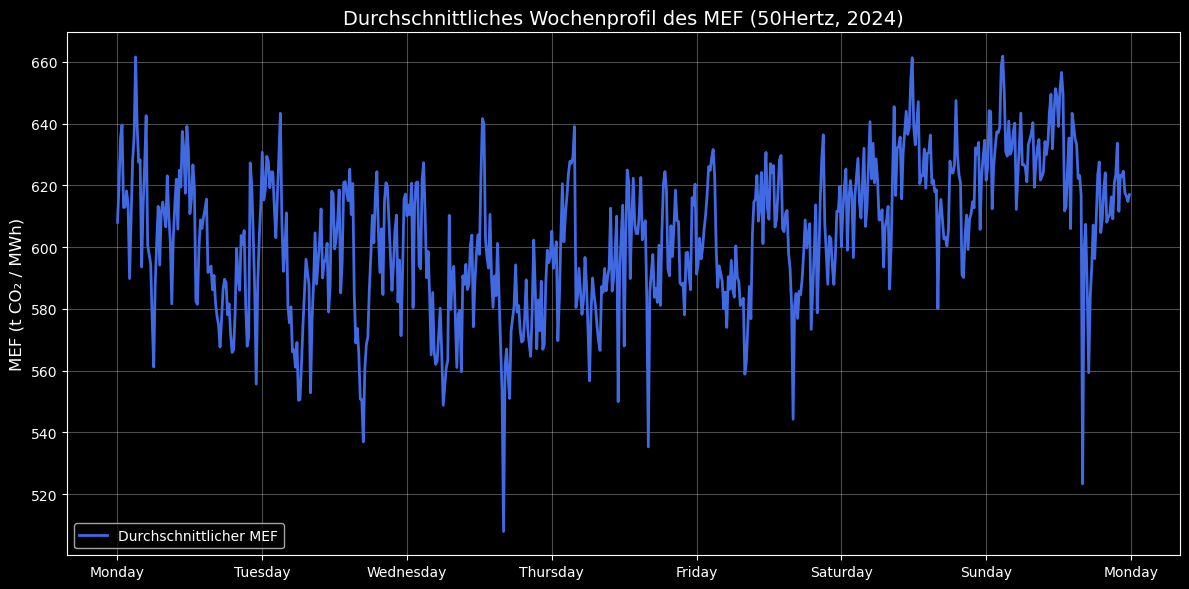

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Gruppieren nach Wochentag (0=Montag, 6=Sonntag) und Uhrzeit
# Ersetze 'mef_t_MWh' durch die Spalte, die du analysieren willst
weekly_avg = fhertz2024.groupby([fhertz2024.index.dayofweek, fhertz2024.index.time])['mef_g_kWh'].mean()

# 2. Der Trick für einen schönen Plot: Einen künstlichen Datetime-Index erstellen!
# Ein MultiIndex (Wochentag, Uhrzeit) lässt sich in Matplotlib schwer als durchgehende Zeitachse plotten.
# Wir mappen die Werte daher einfach auf eine beliebige "Dummy-Woche", die an einem Montag startet (z.B. 01.01.2024).
dummy_week = pd.date_range(start='2024-01-01', periods=len(weekly_avg), freq='15min') # oder '15T' in älteren Pandas-Versionen
weekly_avg.index = dummy_week

# 3. Das Ergebnis plotten
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_avg.index, weekly_avg.values, color='royalblue', linewidth=2, label='Durchschnittlicher MEF')

# X-Achse so formatieren, dass sie Wochentage anzeigt
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%A')) # '%A' steht für den vollen Wochentagnamen

# Optischer Feinschliff
plt.title('Durchschnittliches Wochenprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

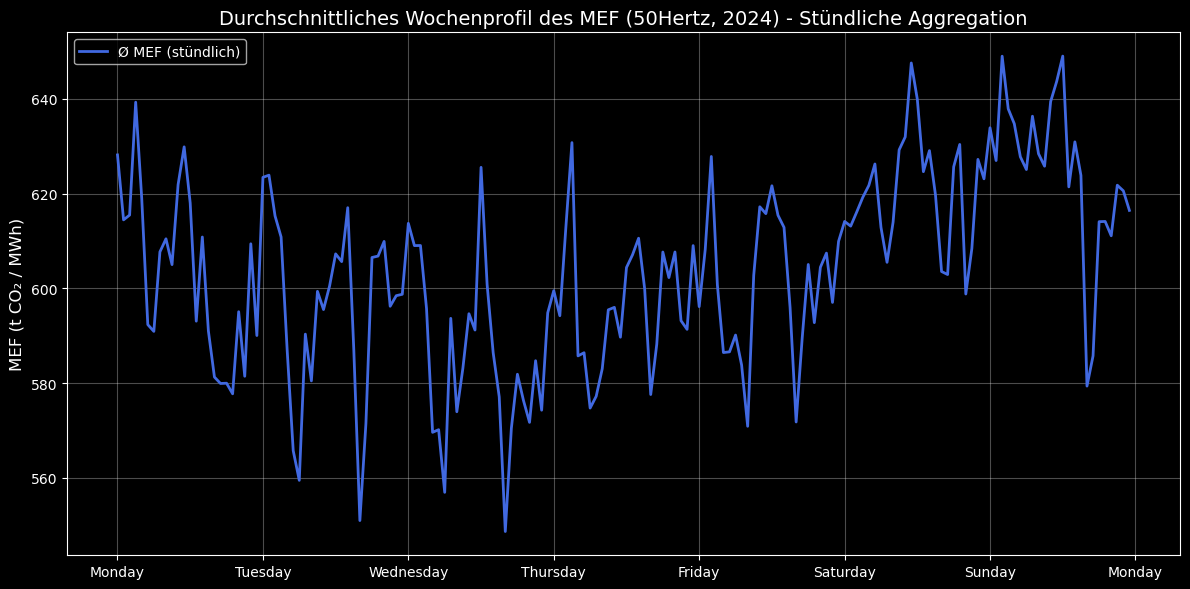

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Daten von 15-Minuten auf Stundenbasis aggregieren
# Für den Emissionsfaktor (MEF) nutzen wir den Durchschnitt (.mean()) der vier Viertelstunden.
df_hourly = fhertz2024[['mef_g_kWh']].resample('1h').mean()

# 2. Gruppieren nach Wochentag (0=Montag, 6=Sonntag) und Uhrzeit
weekly_avg_hourly = df_hourly.groupby([df_hourly.index.dayofweek, df_hourly.index.time])['mef_g_kWh'].mean()

# 3. Dummy-Woche für die X-Achse erstellen
# WICHTIG: Die Frequenz ist jetzt '1H' (Stündlich).
# Das ergibt exakt 168 Datenpunkte (7 Tage * 24 Stunden).
dummy_week = pd.date_range(start='2024-01-01', periods=len(weekly_avg_hourly), freq='1h')
weekly_avg_hourly.index = dummy_week

# 4. Plot erstellen
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_avg_hourly.index, weekly_avg_hourly.values, color='royalblue', linewidth=2, label='Ø MEF (stündlich)')

# X-Achse formatieren (Tage anzeigen)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%A'))

# Optischer Feinschliff
plt.title('Durchschnittliches Wochenprofil des MEF (50Hertz, 2024) - Stündliche Aggregation', fontsize=14)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

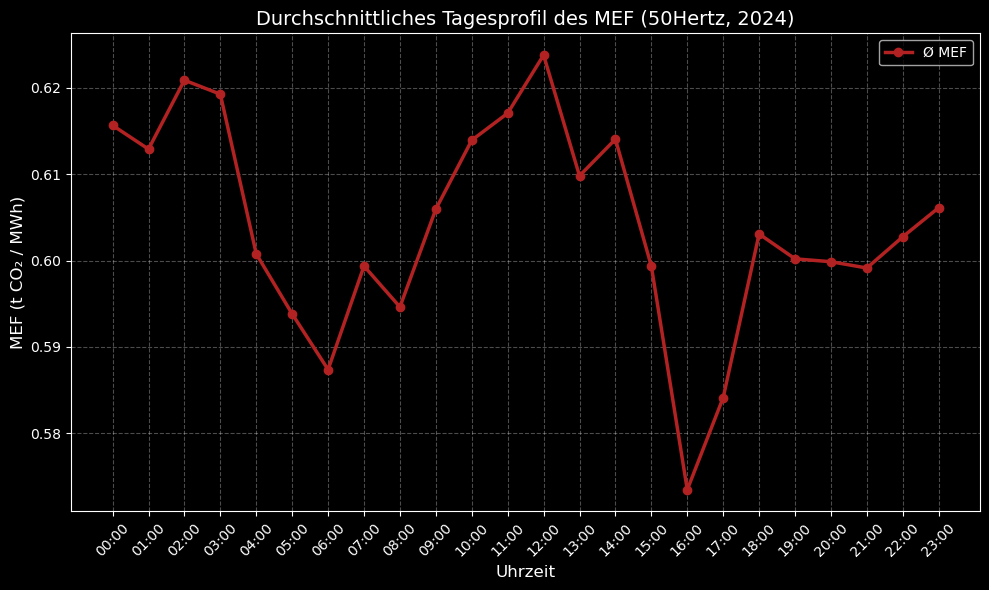

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Daten auf Stundenbasis aggregieren (Mittelwert für den Faktor)
df_hourly = fhertz2024[['mef_t_MWh']].resample('1h').mean()

# 2. Gruppieren nach der Stunde des Tages (0 bis 23)
daily_avg = df_hourly.groupby(df_hourly.index.hour)['mef_t_MWh'].mean()

# 3. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))

# Wir fügen hier Marker ('o') hinzu, damit die 24 einzelnen Stundenpunkte klarer erkennbar sind
ax.plot(daily_avg.index, daily_avg.values, color='firebrick', linewidth=2.5, marker='o', label='Ø MEF')

# X-Achse sauber von 0 bis 23 formatieren
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# Beschriftungen und Layout
plt.title('Durchschnittliches Tagesprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.xlabel('Uhrzeit', fontsize=12)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()

plt.show()

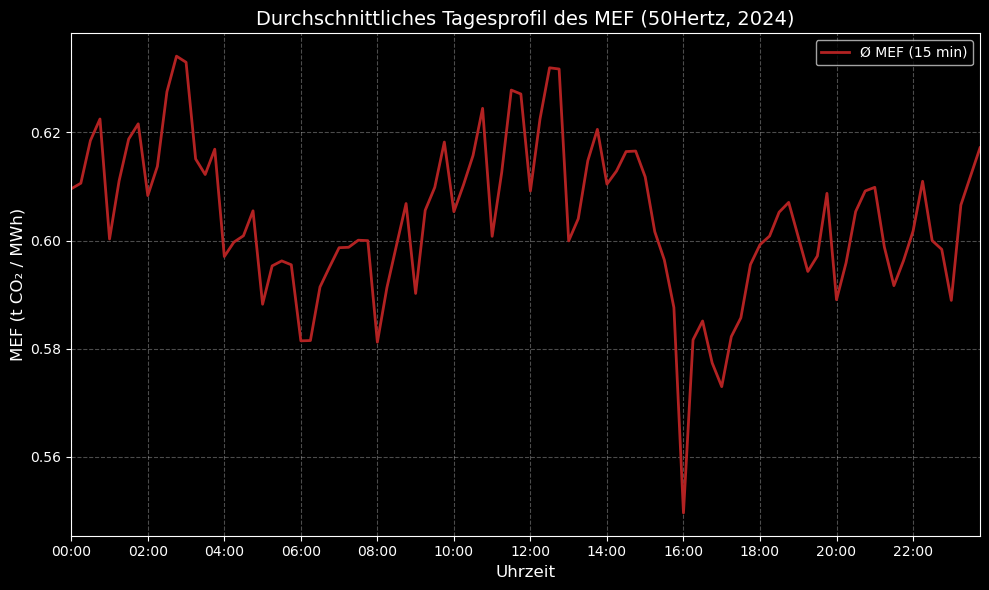

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Direktes Gruppieren nach der exakten Uhrzeit (00:00, 00:15, 00:30, ...)
daily_avg_15min = fhertz2024.groupby(fhertz2024.index.time)['mef_t_MWh'].mean()

# 2. Dummy-Datum für einen einzelnen Tag erstellen (96 Viertelstunden)
dummy_day = pd.date_range(start='2024-01-01', periods=len(daily_avg_15min), freq='15min')
daily_avg_15min.index = dummy_day

# 3. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(daily_avg_15min.index, daily_avg_15min.values, color='firebrick', linewidth=2, label='Ø MEF (15 min)')

# 4. X-Achse formatieren: Ticks z.B. alle 2 Stunden setzen, um Überlappungen zu vermeiden
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Grenzen der X-Achse exakt auf den Tagesanfang und -ende setzen
ax.set_xlim(dummy_day[0], dummy_day[-1])

# Beschriftungen und Layout
plt.title('Durchschnittliches Tagesprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.xlabel('Uhrzeit', fontsize=12)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()

plt.show()

In [8]:
neg = set(fhertz2024.loc[fhertz2024['mef_t_MWh'] < 0, 'mef_g_kWh'])

In [9]:
len(neg)

5

In [10]:
summary = pd.read_json('../results/run_2/amprion_2023/indicators.json')
summary.set_index(summary.timestamp, inplace=True)
summary.index = pd.to_datetime(summary.index, format='ISO8601')
summary = summary.drop(columns=['timestamp'])

In [11]:
coeffs = pd.read_csv('../results/test/coefficients.csv', index_col=['timestamp', 'parameter'], parse_dates=['timestamp'])

In [12]:
coeffs.index.dtypes

timestamp    datetime64[ns, UTC]
parameter                 object
dtype: object

In [13]:
coeffs

coef   std_err       tval  \
timestamp                 parameter                                  
2022-12-30 23:00:00+00:00 p[0->0]    0.834791  0.028073  29.736752   
                          p[1->0]    0.144593  0.032982   4.384005   
                          p[2->0]    0.046639  0.039115   1.192350   
                          p[0->1]    0.132074  0.033833   3.903705   
                          p[1->1]    0.784964  0.046977  16.709429   
...                                       ...       ...        ...   
2023-01-10 08:45:00+00:00 x1[1]      0.885694  0.022029  40.206633   
                          x1[2]      0.718630  0.051656  13.911846   
                          sigma2[0]  0.040827  0.008486   4.810812   
                          sigma2[1]  0.026741  0.004961   5.390349   
                          sigma2[2]  1.684410  0.188526   8.934625   

                                              pval  ci_lower  ci_upper  
timestamp                 parameter                                     
2022-12-30 23:00:00+00:00 p[0->0]    2.572806e-194  0.779770  0.889812  
                          p[1->0]     1.165170e-05  0.079950  0.209237  
                          p[2->0]     2.331240e-01 -0.030025  0.123303  
                          p[0->1]     9.473122e-05  0.065763  0.198386  
                          p[1->1]     1.119016e-62  0.692890  0.877037  
...                                            ...       ...       ...  
2023-01-10 08:45:00+00:00 x1[1]       0.000000e+00  0.842518  0.928869  
                          x1[2]       5.367568e-44  0.617386  0.819874  
                          sigma2[0]   1.503183e-06  0.024194  0.057460  
                          sigma2[1]   7.032096e-08  0.017018  0.036465  
                          sigma2[2]   4.085609e-19  1.314906  2.053914  

[14181 rows x 6 columns]